In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
from IPython.display import display
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('../data/cleaned_energy_demand.csv')

In [22]:
display(df)

,date,demand,min_temperature,max_temperature,solar_exposure,rainfall,school_day,holiday,month,day_of_week,is_weekend
0,2015-01-01,99635.030,13.3,26.9,23.6,0.0,0,1,1,3,0
1,2015-01-02,129606.010,15.4,38.8,26.8,0.0,0,0,1,4,0
2,2015-01-03,142300.540,20.0,38.2,26.5,0.0,0,0,1,5,1
3,2015-01-04,104330.715,16.3,21.4,25.2,4.2,0,0,1,6,1
4,2015-01-05,118132.200,15.0,22.0,30.7,0.0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...
2101,2020-10-02,99585.835,12.8,26.0,22.0,0.0,0,0,10,4,0
2102,2020-10-03,92277.025,17.4,29.4,19.8,0.0,0,0,10,5,1
2103,2020-10-04,94081.565,13.5,29.5,8.4,0.0,0,0,10,6,1
2104,2020-10-05,113610.030,9.1,12.7,7.3,12.8,0,0,10,0,0


In [18]:
df.dtypes

date                object
demand             float64
min_temperature    float64
max_temperature    float64
solar_exposure     float64
rainfall           float64
school_day           int64
holiday              int64
month                int64
day_of_week          int64
is_weekend           int64
dtype: object

In [23]:
x = df.drop(columns=['demand', 'date'])
y = df['demand']

In [10]:
print(x.shape, y.shape)

(2106, 10) (2106,)


In [24]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [25]:
print("===== Data Split Complete =====")
print(f"Full Dataset Shape: {df.shape}")
print(f"x_train Shape     : {x_train.shape} | y_train Shape: {y_train.shape}")
print(f"x_test Shape      : {x_test.shape}  | y_test Shape : {y_test.shape}")
print("===============================")

===== Data Split Complete =====
Full Dataset Shape: (2106, 11)
x_train Shape     : (1684, 9) | y_train Shape: (1684,)
x_test Shape      : (422, 9)  | y_test Shape : (422,)


In [26]:
linear_model = LinearRegression()
rf_model = RandomForestRegressor(random_state = 42, n_estimators = 100)

In [27]:
print("⏳ Training models...")
linear_model.fit(x_train, y_train)
rf_model.fit(x_train, y_train)
print("✅ Training complete!\n")

⏳ Training models...
✅ Training complete!



In [28]:
y_pred_linear = linear_model.predict(x_test)
y_pred_rf = rf_model.predict(x_test)

In [29]:
def evaluate_model(y_true, y_pred):

    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred)/y_true)) * 100

    return r2, rmse, mae, mape

In [32]:
linear_metrics = evaluate_model(y_test, y_pred_linear)
rf_metrics = evaluate_model(y_test, y_pred_rf)

In [33]:
print("=================== Model Evaluation Summary ===================")
print(f"{'Metric':<12} | {'Linear Regression (Baseline)':<30} | {'Random Forest (Ensemble)':<25}")
print("-" * 75)
print(f"{'R² Score':<12} | {linear_metrics[0]:<30.4f} | {rf_metrics[0]:<25.4f}")
print(f"{'RMSE':<12} | ${linear_metrics[1]:<30,.2f} | ${rf_metrics[1]:<25,.2f}")
print(f"{'MAE':<12} | ${linear_metrics[2]:<30,.2f} | ${rf_metrics[2]:<25,.2f}")
print(f"{'MAPE':<12} | {linear_metrics[3]:<30.2f}% | {rf_metrics[3]:<25.2f}%")
print("================================================================")

=================== Model Evaluation Summary ===================
Metric       | Linear Regression (Baseline)   | Random Forest (Ensemble) 
---------------------------------------------------------------------------
R² Score     | 0.4585                         | 0.8000                   
RMSE         | $10,176.79                      | $6,184.60                 
MAE          | $8,110.93                       | $4,610.31                 
MAPE         | 6.80                          % | 3.91                     %


In [37]:
joblib.dump(linear_model, '../models/linreg_model.pkl')
print("💾 Successfully saved: linreg_model.pkl")

joblib.dump(rf_model, '../models/rf_model.pkl')
print("💾 Successfully saved: rf_model.pkl")

💾 Successfully saved: linreg_model.pkl
💾 Successfully saved: rf_model.pkl


C:\Users\avina\AppData\Local\Temp\ipykernel_37804\3539479792.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_importances, y=sorted_features, ax=ax3, palette='viridis')


📊 Diagnostic suite successfully saved to: ../img/model_diagnostics_suite.png


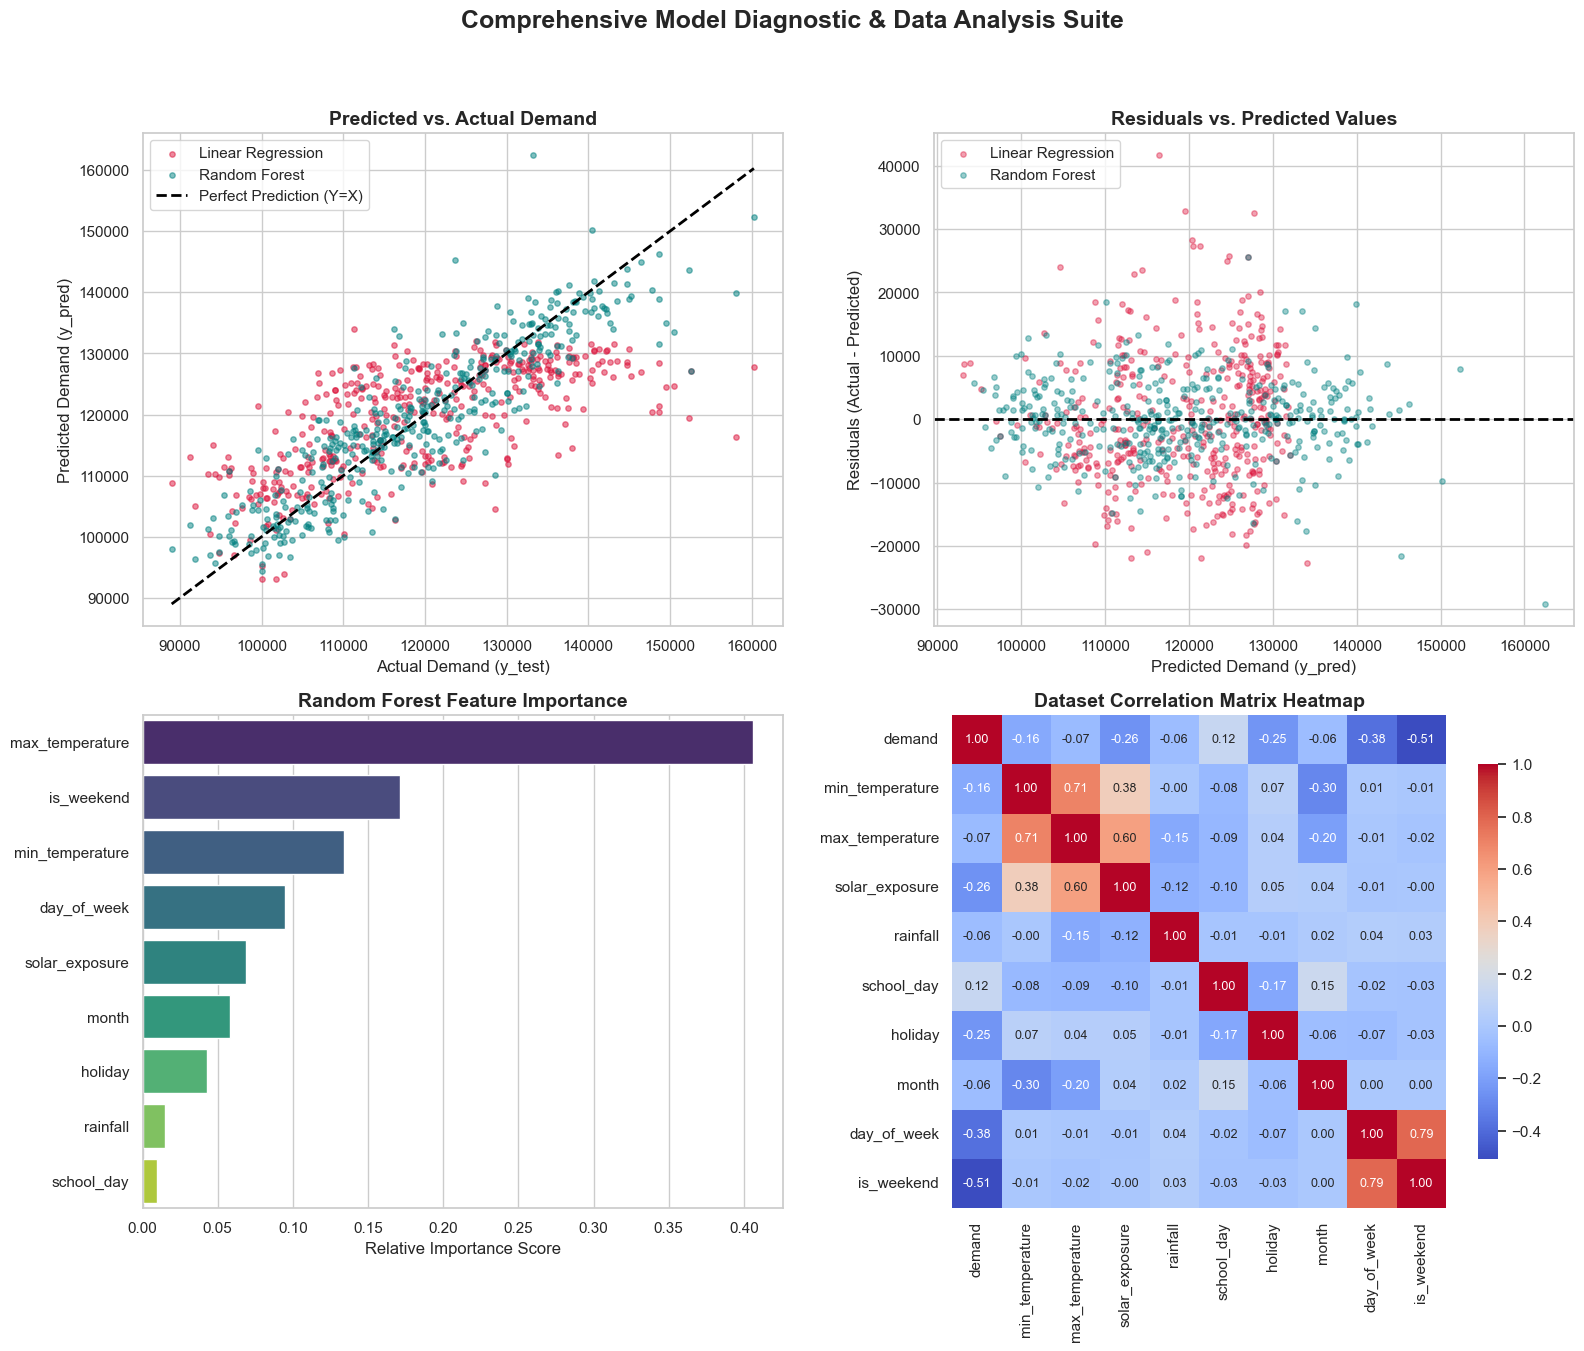

In [42]:
# Calculate Residuals for the plots
residuals_linear = y_test - y_pred_linear
residuals_rf = y_test - y_pred_rf

# Set up global plot configurations
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Comprehensive Model Diagnostic & Data Analysis Suite', fontsize=18, fontweight='bold', y=0.95)

# ==========================================
# PLOT 1: Predicted vs Actual Scatter Plot
# ==========================================
ax1 = axes[0, 0]
ax1.scatter(y_test, y_pred_linear, color='crimson', alpha=0.5, s=15, label='Linear Regression')
ax1.scatter(y_test, y_pred_rf, color='teal', alpha=0.5, s=15, label='Random Forest')

# Add the perfect-fit diagonal reference line (y = x)
ideal_line = np.linspace(min(y_test), max(y_test), 100)
ax1.plot(ideal_line, ideal_line, color='black', linestyle='--', linewidth=2, label='Perfect Prediction (Y=X)')

ax1.set_title('Predicted vs. Actual Demand', fontsize=14, fontweight='bold')
ax1.set_xlabel('Actual Demand (y_test)', fontsize=12)
ax1.set_ylabel('Predicted Demand (y_pred)', fontsize=12)
ax1.legend(loc='upper left')

# ==========================================
# PLOT 2: Residual Analysis Plot
# ==========================================
ax2 = axes[0, 1]
ax2.scatter(y_pred_linear, residuals_linear, color='crimson', alpha=0.4, s=15, label='Linear Regression')
ax2.scatter(y_pred_rf, residuals_rf, color='teal', alpha=0.4, s=15, label='Random Forest')

# Add the horizontal reference line at 0
ax2.axhline(y=0, color='black', linestyle='--', linewidth=2)

ax2.set_title('Residuals vs. Predicted Values', fontsize=14, fontweight='bold')
ax2.set_xlabel('Predicted Demand (y_pred)', fontsize=12)
ax2.set_ylabel('Residuals (Actual - Predicted)', fontsize=12)
ax2.legend(loc='upper left')

# ==========================================
# PLOT 3: Feature Importance & Coefficients
# ==========================================
ax3 = axes[1, 0]
# Fetch feature names and Random Forest importances
feature_names = x.columns
importances = rf_model.feature_importances_

# Sort features by importance
indices = np.argsort(importances)[::-1]
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Plot Random Forest feature importances as a bar chart
sns.barplot(x=sorted_importances, y=sorted_features, ax=ax3, palette='viridis')
ax3.set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
ax3.set_xlabel('Relative Importance Score', fontsize=12)

# ==========================================
# PLOT 4: Correlation Matrix Heatmap
# ==========================================
ax4 = axes[1, 1]
# Compute correlation matrix on the cleaned dataframe (including target)
corr_matrix = df.drop(columns=['date']).corr()

# Plot the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            square=True, cbar_kws={"shrink": .8}, ax=ax4, annot_kws={"size": 9})
ax4.set_title('Dataset Correlation Matrix Heatmap', fontsize=14, fontweight='bold')

# Adjust layout and save the multi-plot grid
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig('../img/model_diagnostics_suite.png', dpi=300, bbox_inches='tight')
print(f"📊 Diagnostic suite successfully saved to: ../img/model_diagnostics_suite.png")
plt.show()